##                                                               **UnSupervised Learning**




# **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: store_customers.csv     


# **Data_Preprocessing**

In [ ]:
df=pd.read_csv('/content/store_customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0
999,1999,M,67.0,107.8,1.0


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].mean())

# Gender (categorical → mode use karo)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df= df.dropna()

In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df=df.drop('Gender',axis=1)

In [ ]:
df = df.drop('CustomerID', axis=1)

In [ ]:
df.var()

,0
Age,178.478358
Annual Income (k$),816.309719
Spending Score (1-100),401.646995


In [ ]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]

# **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# **K-Means Algorithm**

In [ ]:
model = KMeans(n_clusters=5)
model.fit(x_scaled)

KMeans(n_clusters=5)

In [ ]:
labels = model.labels_
centroid = model.cluster_centers_
print("Labels : ",labels)
print("Centroid : ",centroid)

Labels :  [1 4 2 2 1 3 2 2 4 1 3 1 1 3 3 1 1 4 1 3 2 1 1 4 3 4 3 4 4 4 1 2 1 3 4 1 1
 3 3 1 0 4 1 1 3 1 3 1 1 3 1 1 1 2 2 2 3 1 1 2 3 4 3 3 2 2 1 2 1 1 4 0 3 2
 3 1 4 4 3 3 4 4 2 1 4 3 2 4 3 1 4 1 1 3 1 3 1 3 1 1 3 3 1 4 4 4 0 4 1 1 3
 4 1 0 1 4 1 4 2 2 0 3 2 3 2 0 3 3 1 3 3 4 3 4 1 2 1 4 2 3 4 2 3 2 3 2 3 4
 2 1 4 4 3 1 4 3 2 4 3 2 3 2 2 3 2 4 2 0 1 3 3 4 4 4 1 2 1 2 1 0 2 3 1 3 3
 2 1 2 4 3 4 2 4 3 2 4 3 3 4 3 1 1 2 2 3 3 1 1 1 0 2 2 1 1 4 2 3 4 1 1 0 3
 1 3 1 2 1 1 4 2 3 1 1 1 2 1 3 3 3 4 4 3 2 2 1 4 3 3 2 2 1 2 2 2 3 1 2 3 1
 2 3 3 3 3 1 3 2 1 3 1 2 3 2 3 4 4 4 3 1 1 1 2 2 3 2 1 4 2 4 1 3 1 4 2 4 1
 2 4 2 2 1 1 2 2 1 1 2 1 4 1 1 2 2 2 2 4 4 1 1 4 1 2 3 0 3 3 2 2 4 4 1 3 1
 3 2 1 3 1 4 3 3 1 1 3 3 1 4 3 3 1 1 2 1 3 1 1 1 1 1 3 1 0 4 1 2 4 1 1 2 4
 1 4 2 2 2 1 2 4 2 4 3 3 3 3 3 1 1 2 2 4 4 4 3 2 2 4 3 2 4 2 1 3 1 1 4 2 1
 1 1 4 4 3 4 2 1 4 2 1 1 4 0 0 1 1 2 2 1 2 2 3 3 3 4 2 2 4 2 3 3 1 4 1 3 4
 4 2 4 3 1 3 1 2 3 4 3 3 1 3 3 3 2 1 1 1 4 4 2 0 4 3 4 3 3 2 2 3 2 1 0 2 4
 4 3 4 1 3 1 1 

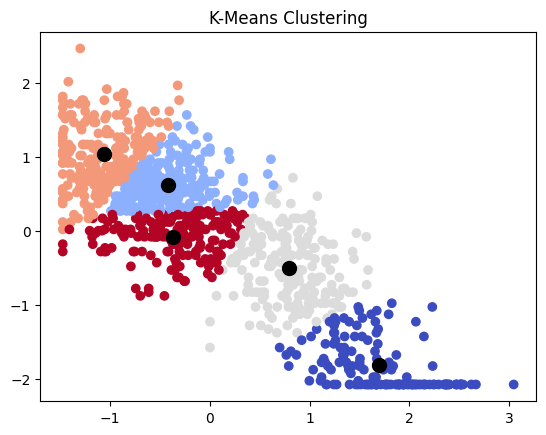

In [ ]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=labels,cmap='coolwarm')
plt.scatter(centroid[:,0],centroid[:,1],color='black', s= 100,marker = 'o')
plt.title("K-Means Clustering")
plt.show()

#**Elbow-Method**

In [ ]:
wcss=[]
for i in range(1,11):
  model=KMeans(n_clusters=i)
  model.fit(x_scaled)
  wcss.append(model.inertia_)

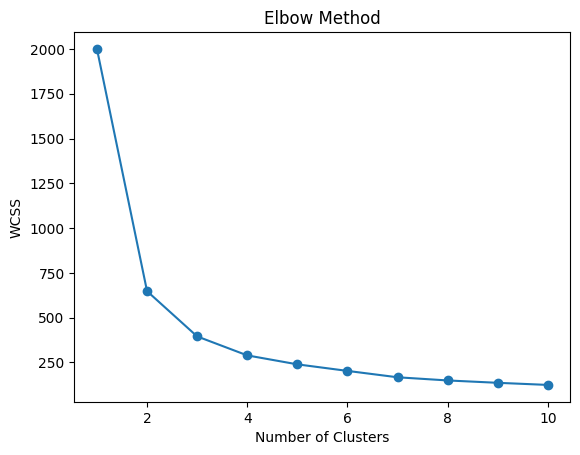

In [ ]:
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
for i in range(2,11):
  model = KMeans(n_clusters=i)
  labels = model.fit_predict(x_scaled)
  score = silhouette_score(x_scaled,labels)
  print(f'k = {i} , Score = {score}')

k = 2 , Score = 0.5841850838265088
k = 3 , Score = 0.47709553995771525
k = 4 , Score = 0.39305398862391977
k = 5 , Score = 0.36718799388636686
k = 6 , Score = 0.34865849573094654
k = 7 , Score = 0.375572108814564
k = 8 , Score = 0.3610664443045907
k = 9 , Score = 0.3454522826280143
k = 10 , Score = 0.3313289854535916


# **Hierarchical Clustering**

**Importing libraries**

In [ ]:
from scipy.cluster.hierarchy import linkage , dendrogram
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

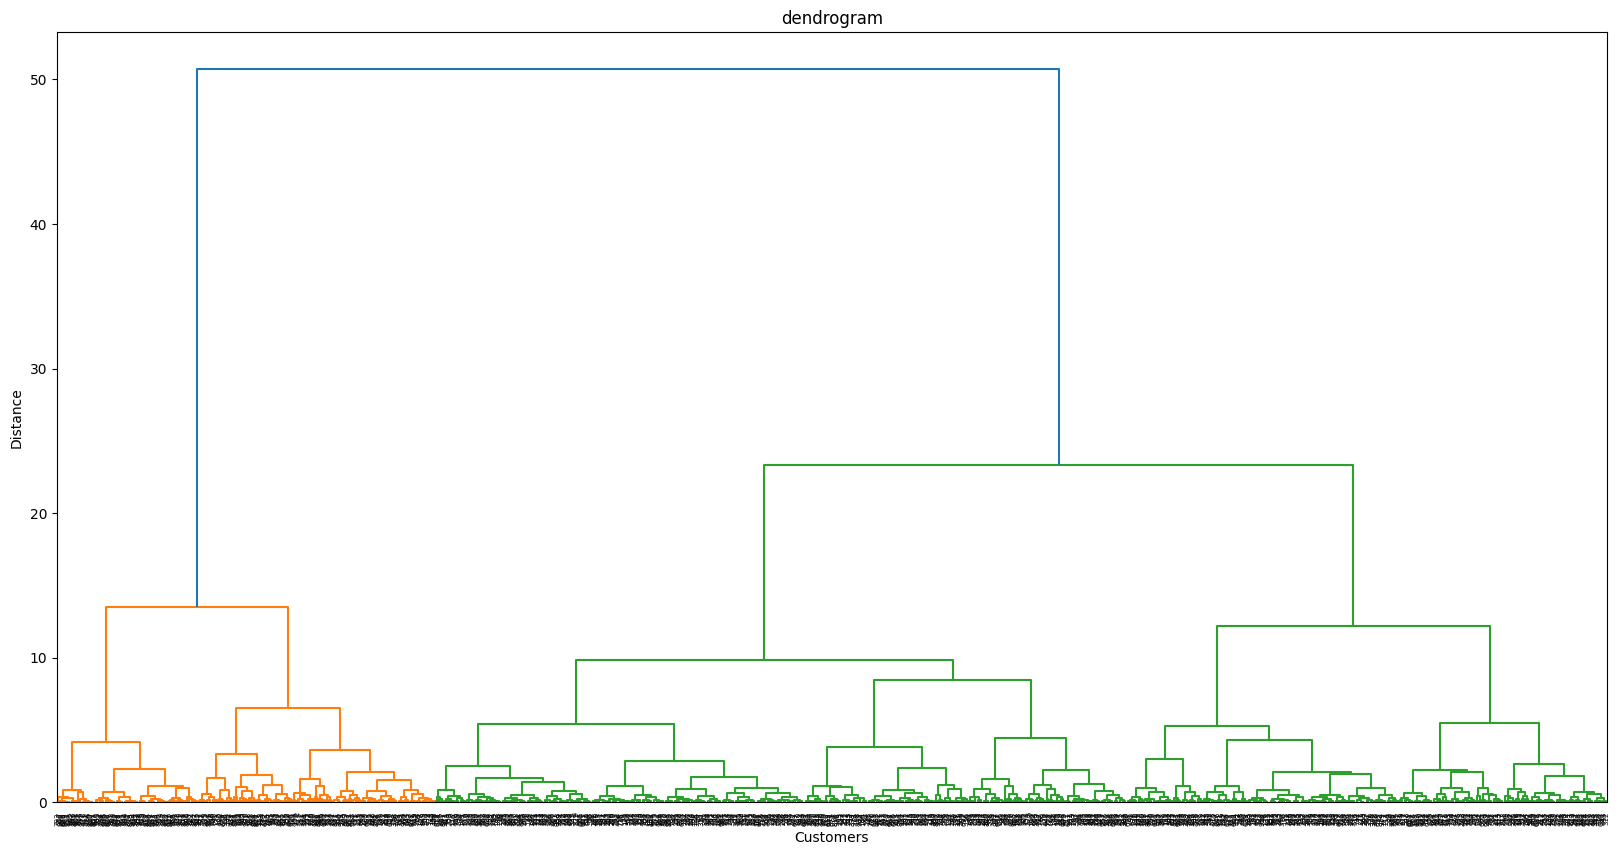

In [ ]:
linked = linkage (x_scaled,method ='ward')
plt.figure(figsize=(20,10))
dendrogram(linked)
plt.title("dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for i in range(2, 11):   # 1 se start mat karo ⚠️
    hc = AgglomerativeClustering(n_clusters=i)
    labels = hc.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f'k = {i}, Score = {score}')

k = 2, Score = 0.5748040107850048
k = 3, Score = 0.4095201579257073
k = 4, Score = 0.3853263989904665
k = 5, Score = 0.35494996016198216
k = 6, Score = 0.3108712867641123
k = 7, Score = 0.3354639951482483
k = 8, Score = 0.3179743741799039
k = 9, Score = 0.3091695606664166
k = 10, Score = 0.29365235048107574


In [ ]:
hc = AgglomerativeClustering(n_clusters=2)
labels = hc.fit_predict(x_scaled)
score = silhouette_score(x_scaled, labels)
print(f'Score = {score}')

Score = 0.5748040107850048


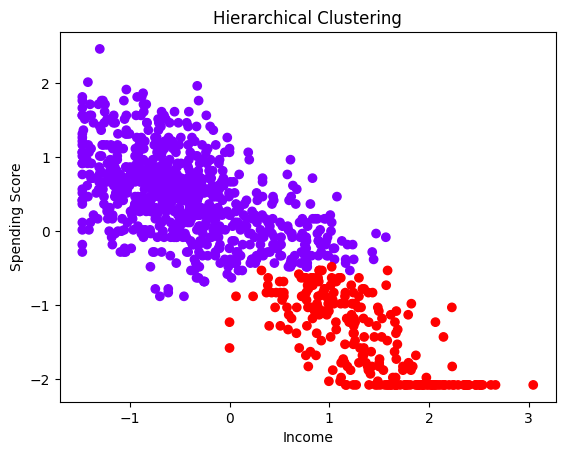

In [ ]:
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

# **DBSCAN Algorithm**

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
db = DBSCAN(eps=0.4,min_samples=5)
labels = db.fit_predict(x_scaled)

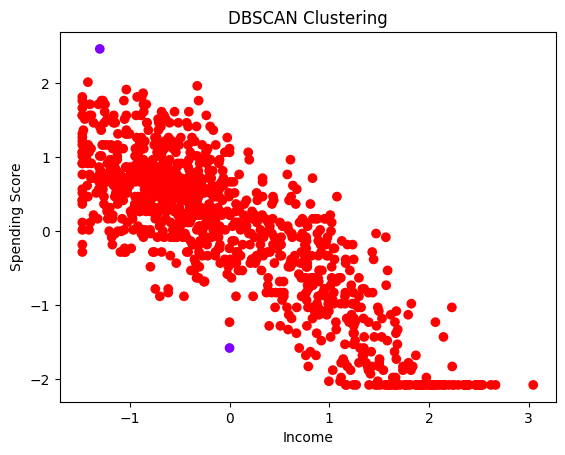

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=labels,cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x_scaled, labels)
print(score)

0.3216344729067285


In [ ]:
import numpy as np

print("Unique labels:", set(labels))

Unique labels: {np.int64(0), np.int64(-1)}


In [ ]:
from sklearn.decomposition import PCA #Principle Component Analysis
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

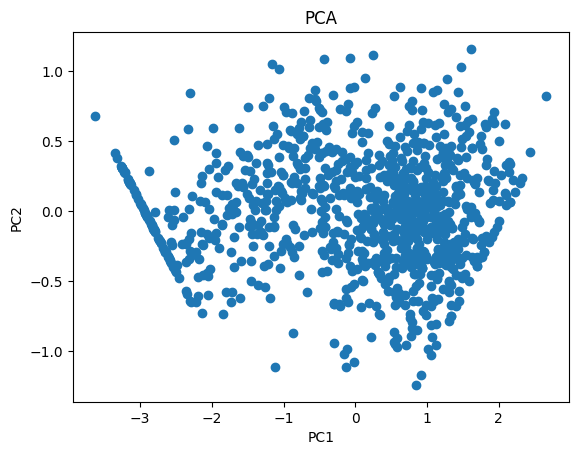

In [ ]:
plt.scatter(x_pca[:,0],x_pca[:,1])
plt.title("PCA")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
print(pca.explained_variance_ratio_)

[0.92054219 0.07945781]


In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2)
labels = model.fit_predict(x_pca)

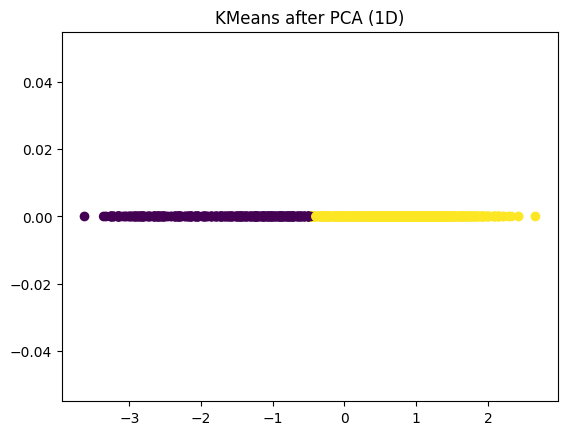

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x_pca[:,0], [0]*len(x_pca), c=labels, cmap='viridis')
plt.title("KMeans after PCA (1D)")
plt.show()

In [ ]:
!pip install mlxtend

In [ ]:
import pandas as pd

data = [
    ['Bread', 'Butter'],
    ['Bread', 'Milk'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter', 'Milk'],
    ['Bread', 'Butter']
]

df = pd.DataFrame(data)

In [ ]:
print(df)

       0       1     2
0  Bread  Butter  None
1  Bread    Milk  None
2   Milk  Butter  None
3  Bread  Butter  Milk
4  Bread  Butter  None


In [ ]:
from mlxtend.preprocessing import TransactionEncoder
te=TransactionEncoder()
te_data = te.fit(data).transform(data)
df=pd.DataFrame(te_data,columns=te.columns_)
print(df)

   Bread  Butter   Milk
0   True    True  False
1   True   False   True
2  False    True   True
3   True    True   True
4   True    True  False
